# HW6-2: Численное моделирование задачи двух тел

## 1. Постановка задачи

Необходимо получить траекторию движения спутника, решая систему дифференциальных уравнений, описывающую задачу двух тел:

$$
\begin{cases}
x' = z \\
y' = u \\
z' = -\frac{x}{(x^2 + y^2)^{3/2}} \\
u' = -\frac{y}{(x^2 + y^2)^{3/2}}
\end{cases}
$$

**Начальные условия:**
$x(0) = 0.5, \quad y(0) = 0, \quad z(0) = 0, \quad u(0) = \sqrt{3} \approx 1.73$.

**Интервал времени:** $0 < t \le 20$.

## 2. Выбранные численные методы
Согласно заданию, выбраны 3 метода с порядком аппроксимации $p > 1$:
1.  **Метод трапеций** (неявный, 2-й порядок).
2.  **Метод Рунге-Кутты 2-го порядка (схема Хойна)** с экстраполяцией Ричардсона (эффективный порядок $\approx 3$).
3.  **Классический метод Рунге-Кутты 4-го порядка** с экстраполяцией Ричардсона (эффективный порядок $\approx 5$).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Параметры задачи
T_END = 20.0
Y0 = np.array([0.5, 0.0, 0.0, np.sqrt(3)]) # x, y, z(vx), u(vy)

def system_rhs(t, w):
    """
    Правая часть системы уравнений.
    w = [x, y, z, u]
    """
    x, y, z, u = w
    r2 = x**2 + y**2
    r3 = r2**(1.5)
    
    dx = z
    dy = u
    dz = -x / r3
    du = -y / r3
    
    return np.array([dx, dy, dz, du])

def calc_energy(w):
    """Вычисление полной энергии системы для проверки"""
    x, y, z, u = w
    r = np.sqrt(x**2 + y**2)
    v2 = z**2 + u**2
    return v2/2 - 1/r

## 3. Реализация методов

### 3.1. Метод трапеций (Implicit Trapezoidal Rule)
Схема: $y_{n+1} = y_n + \frac{\tau}{2} (f(t_n, y_n) + f(t_{n+1}, y_{n+1}))$.
Так как система нелинейная, используем метод простых итераций для нахождения $y_{n+1}$ на каждом шаге.

### 3.2. и 3.3. Методы Рунге-Кутты с экстраполяцией Ричардсона
Используем правило Рунге (экстраполяцию Ричардсона) для повышения точности.
Если $Y_{\tau}$ — результат с шагом $\tau$, а $Y_{\tau/2}$ — результат двух шагов с шагом $\tau/2$, то уточненное значение:
$$ R(\tau) = \frac{2^p Y_{\tau/2} - Y_{\tau}}{2^p - 1} $$

In [2]:
# --- Базовые методы ---

def rk2_step(f, t, y, h):
    k1 = f(t, y)
    k2 = f(t + h, y + h * k1)
    return y + (h / 2.0) * (k1 + k2)

def rk4_step(f, t, y, h):
    k1 = f(t, y)
    k2 = f(t + h/2, y + (h/2) * k1)
    k3 = f(t + h/2, y + (h/2) * k2)
    k4 = f(t + h, y + h * k3)
    return y + (h / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

def trapezoidal_step(f, t, y, h, tol=1e-9, max_iter=10):
    # Простая итерация для неявного метода
    y_pred = y + h * f(t, y) # Предиктор (Эйлер)
    y_next = y_pred
    
    f_curr = f(t, y)
    
    for _ in range(max_iter):
        y_next_new = y + (h / 2.0) * (f_curr + f(t + h, y_next))
        if np.linalg.norm(y_next_new - y_next) < tol:
            return y_next_new
        y_next = y_next_new
    return y_next

# --- Обертка с Ричардсоном ---

def solve_with_richardson(base_method, p_order, f, y0, t_end, h):
    t = 0
    y = y0.copy()
    
    ts = [t]
    ys = [y]
    energies = [calc_energy(y)]
    
    while t < t_end - 1e-9:
        if t + h > t_end:
            h = t_end - t
            
        # Шаг h
        y1 = base_method(f, t, y, h)
        
        # Два шага h/2
        y_mid = base_method(f, t, y, h/2)
        y2 = base_method(f, t + h/2, y_mid, h/2)
        
        # Экстраполяция
        y_rich = (2**p_order * y2 - y1) / (2**p_order - 1)
        
        y = y_rich
        t += h
        
        ts.append(t)
        ys.append(y)
        energies.append(calc_energy(y))
        
    return np.array(ts), np.array(ys), np.array(energies)

def solve_simple(base_method, f, y0, t_end, h):
    t = 0
    y = y0.copy()
    ts = [t]; ys = [y]; energies = [calc_energy(y)]
    while t < t_end - 1e-9:
        y = base_method(f, t, y, h)
        t += h
        ts.append(t); ys.append(y); energies.append(calc_energy(y))
    return np.array(ts), np.array(ys), np.array(energies)

## 4. Расчет и траектории

Проведем расчет с фиксированным шагом $h = 0.05$.

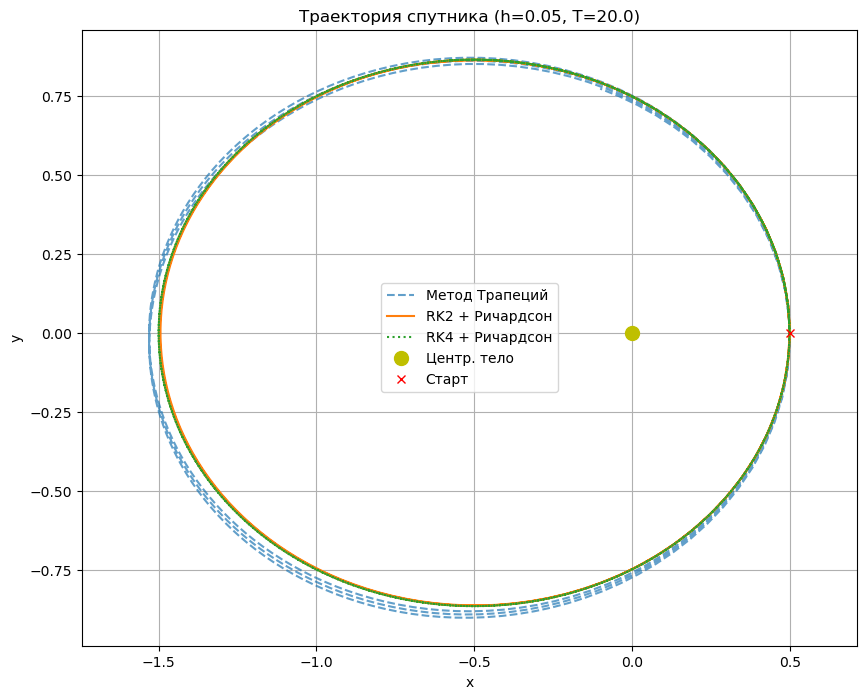

In [3]:
h_fixed = 0.05

# 1. Метод Трапеций (без Ричардсона, p=2)
ts_trap, ys_trap, en_trap = solve_simple(trapezoidal_step, system_rhs, Y0, T_END, h_fixed)

# 2. RK2 + Ричардсон (базовый p=2, итоговый p~3)
ts_rk2r, ys_rk2r, en_rk2r = solve_with_richardson(rk2_step, 2, system_rhs, Y0, T_END, h_fixed)

# 3. RK4 + Ричардсон (базовый p=4, итоговый p~5)
ts_rk4r, ys_rk4r, en_rk4r = solve_with_richardson(rk4_step, 4, system_rhs, Y0, T_END, h_fixed)

# Визуализация
plt.figure(figsize=(10, 8))
plt.plot(ys_trap[:, 0], ys_trap[:, 1], label='Метод Трапеций', linestyle='--', alpha=0.7)
plt.plot(ys_rk2r[:, 0], ys_rk2r[:, 1], label='RK2 + Ричардсон')
plt.plot(ys_rk4r[:, 0], ys_rk4r[:, 1], label='RK4 + Ричардсон', linestyle=':')
# Начальная точка (планета)
plt.plot(0, 0, 'yo', markersize=10, label='Центр. тело')
plt.plot(Y0[0], Y0[1], 'rx', label='Старт')

plt.title(f'Траектория спутника (h={h_fixed}, T={T_END})')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.legend()
plt.grid(True)
plt.show()

## 5. Эффект изменения фазы (Фазовый сдвиг)

Ключевым инвариантом является полная энергия $E$. Для орбиты период обращения $T$ жестко связан с энергией: $T \sim (-E)^{-3/2}$. 

Методы невысокого порядка приводят к **численной диссипации или генерации энергии** (дрейфу энергии). 

1.  Если численная энергия $E_{num}$ меняется, меняется численная большая полуось $a_{num}$.
2.  Изменение $a_{num}$ влечет изменение периода обращения $T_{num}$.
3.  Даже малая ошибка в периоде $\Delta T$ накапливается с каждым оборотом. Спутник приходит в ту же геометрическую точку раньше или позже, чем в точном решении.

Этот эффект называется **фазовым сдвигом** (или фазовой ошибкой). Траектория может выглядеть правильной (эллипс), но положение спутника на ней со временем будет сильно отличаться от истинного

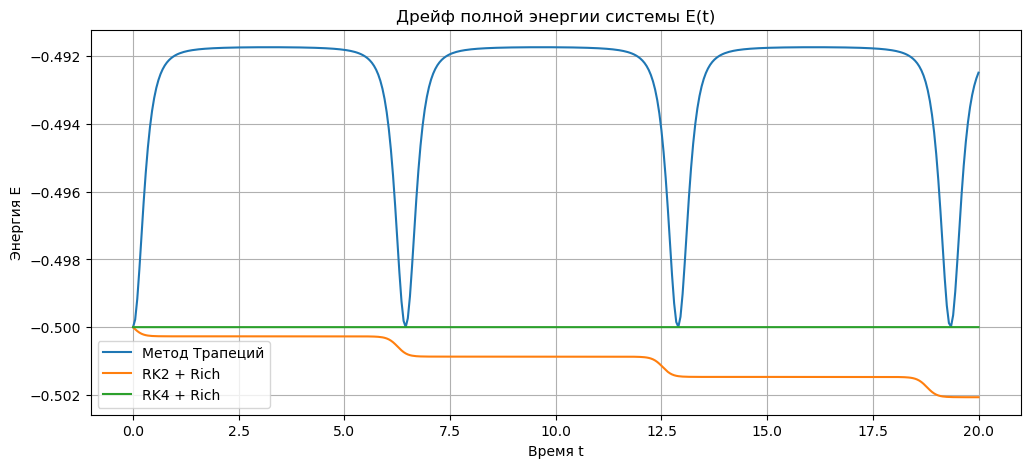

Ошибка энергии (Трапеции): 7.52e-03
Ошибка энергии (RK2+Rich): 2.07e-03
Ошибка энергии (RK4+Rich): 5.53e-07


In [4]:
plt.figure(figsize=(12, 5))
plt.plot(ts_trap, en_trap, label='Метод Трапеций')
plt.plot(ts_rk2r, en_rk2r, label='RK2 + Rich')
plt.plot(ts_rk4r, en_rk4r, label='RK4 + Rich')

plt.title('Дрейф полной энергии системы E(t)')
plt.xlabel('Время t')
plt.ylabel('Энергия E')
plt.legend()
plt.grid(True)
plt.show()

print(f"Ошибка энергии (Трапеции): {abs(en_trap[-1] - en_trap[0]):.2e}")
print(f"Ошибка энергии (RK2+Rich): {abs(en_rk2r[-1] - en_rk2r[0]):.2e}")
print(f"Ошибка энергии (RK4+Rich): {abs(en_rk4r[-1] - en_rk4r[0]):.2e}")

## 6. Расчет с автоматическим выбором шага (Метод 1-го порядка)

Реализуем **Явный метод Эйлера (1-й порядок)** с автоматическим выбором шага на основе правила Рунге.

**Алгоритм:**
1. Делаем шаг $h$: $y_1 = y_n + h f(y_n)$.
2. Делаем два шага $h/2$: $y_{tmp} = y_n + \frac{h}{2} f(y_n)$, $y_2 = y_{tmp} + \frac{h}{2} f(y_{tmp})$.
3. Оценка локальной погрешности: $\epsilon \approx |y_1 - y_2|$.
4. Если $\epsilon > tol$, уменьшаем шаг ($h \to h/2$) и повторяем.
5. Если $\epsilon \le tol$, принимаем шаг ($y_{n+1} = y_2$, так как он точнее). Если $\epsilon < tol / 64$, пробуем увеличить шаг ($h \to 2h$) для следующей итерации.

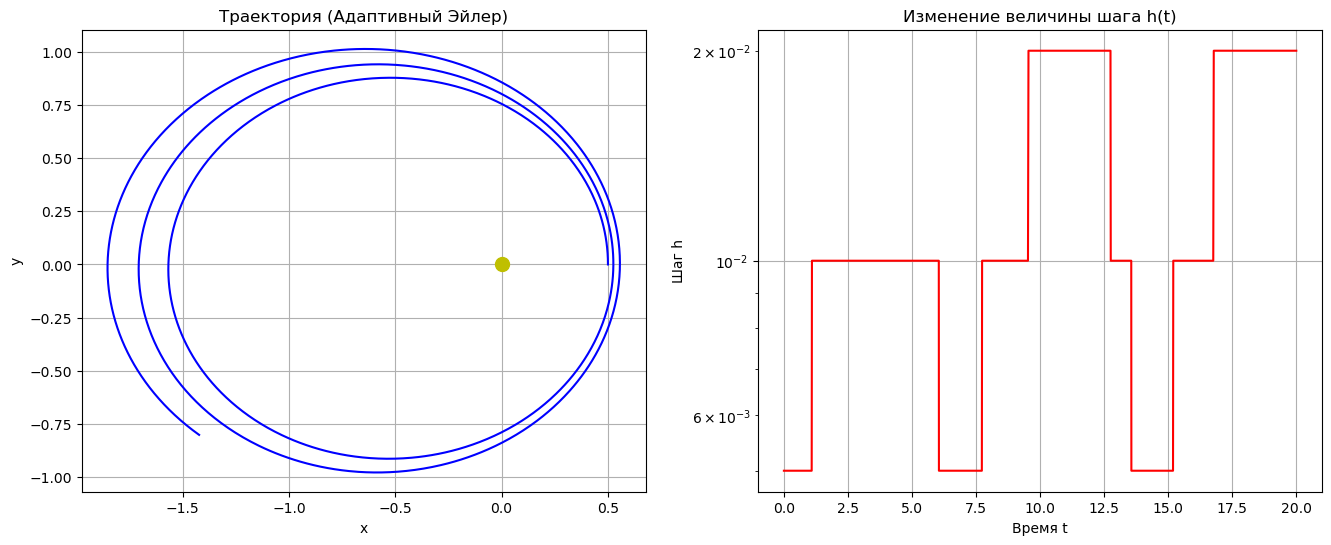

In [5]:
def euler_step(f, t, y, h):
    return y + h * f(t, y)

def solve_adaptive_euler(f, y0, t_end, tol=1e-4):
    t = 0
    y = y0.copy()
    h = 0.01 # Начальный шаг
    
    ts = [t]
    ys = [y]
    hs = [h]
    
    while t < t_end:
        if t + h > t_end:
            h = t_end - t
            
        # 1. Шаг h
        y1 = euler_step(f, t, y, h)
        
        # 2. Два шага h/2
        y_half = euler_step(f, t, y, h/2)
        y2 = euler_step(f, t + h/2, y_half, h/2)
        
        # 3. Оценка ошибки (для метода 1-го порядка)
        # Runge rule: eps ~ |y1 - y2|
        error = np.linalg.norm(y1 - y2)
        
        if error > tol:
            # Ошибка велика, уменьшаем шаг
            h /= 2.0
            continue
        else:
            # Шаг принят
            t += h
            y = y2 # Берем более точное значение
            
            ts.append(t)
            ys.append(y)
            hs.append(h)
            
            # Если ошибка очень мала, увеличиваем шаг
            if error < tol / 10.0:
                h *= 2.0
                
    return np.array(ts), np.array(ys), np.array(hs)

# Запуск адаптивного Эйлера
tol_val = 1e-4
ts_ad, ys_ad, hs_ad = solve_adaptive_euler(system_rhs, Y0, T_END, tol=tol_val)

# Визуализация траектории и шага
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(ys_ad[:, 0], ys_ad[:, 1], 'b-', label='Adaptive Euler')
ax1.plot(0, 0, 'yo', markersize=10)
ax1.set_title('Траектория (Адаптивный Эйлер)')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.axis('equal')
ax1.grid(True)

ax2.plot(ts_ad[1:], hs_ad[1:], 'r-')
ax2.set_title('Изменение величины шага h(t)')
ax2.set_xlabel('Время t')
ax2.set_ylabel('Шаг h')
ax2.set_yscale('log')
ax2.grid(True)

plt.show()

## 7. Выводы

1.  **Сравнение методов:** Методы высокого порядка (RK4 + Ричардсон) обеспечивают наилучшее сохранение формы орбиты и энергии. Метод трапеций (2-й порядок) при таком же шаге дает заметную ошибку в энергии.
2.  **Фазовый сдвиг:** На графике энергии видно, что методы низкого порядка приводят к линейному (или более сложному) уходу энергии от константы. Это меняет период обращения спутника. В результате, даже если орбита остается замкнутой, спутник оказывается в "неправильной" точке орбиты для данного момента времени $t$. 
3.  **Адаптивный шаг:** 
    На графике $h(t)$ четко видны периодические провалы. Это происходит, когда спутник проходит **перицентр** (ближайшую точку к планете, $r=0.5$). 
    * В перицентре скорость максимальна ($v = \sqrt{3}$), а кривизна траектории наибольшая.
    * Производные функции (силы) меняются быстро (градиент сил $\sim 1/r^3$).
    * Чтобы удержать ошибку 1-го порядка в пределах `tol`, алгоритм вынужден резко уменьшать шаг. 
    * В апоцентре (дальней точке), где скорость мала и изменения плавные, шаг увеличивается.

Это демонстрирует необходимость использования схем с переменным шагом (или методов высокого порядка) для задач небесной механики с высоким эксцентриситетом.